# 03 — Smart approach: VAD + ASR + LLM

**Goal:** Build a "smart" endpointing system. Instead of relying purely on silence (which fails when users pause to think), we'll use Silero VAD, transcribe the speech using Whisper, and ask an LLM to decide if the user is truly done.

The LLM will classify the text as:
- `finished`: The user completed their thought (agent can respond).
- `unfinished`: The user paused mid-sentence (agent should wait).
- `wait`: The user explicitly asked the agent to hold on (e.g., "wait a second").

**Why ONNX instead of `torch.hub.load`:** the pip-installed silero-vad package imports `torchaudio`, which has an ABI mismatch with our conda torch. Using the ONNX model directly via `onnxruntime` bypasses that — and is actually closer to how production systems run VAD anyway (faster, lighter, no torch dependency at inference).

In [ ]:
import os
import json
import numpy as np
import onnxruntime as ort
import librosa
import librosa.display
import matplotlib.pyplot as plt
import whisper
# import google.generativeai as genai
from openai import OpenAI
import time

client = OpenAI(
    api_key="api_key",
    base_url="https://openrouter.ai/api/v1"
)
MODEL_PATH = '../models/silero_vad.onnx'
DATA_DIR = '../data'

print('onnxruntime:', ort.__version__)
print('librosa    :', librosa.__version__)
print('Whisper    :', whisper.__version__)

onnxruntime: 1.25.1
librosa    : 0.11.0
Whisper    : 20250625


## SileroVAD wrapper

Silero VAD takes 32ms chunks (512 samples at 16kHz) and outputs a per-chunk probability of speech. The model is stateful — we pass the LSTM state forward across chunks so the model sees temporal context.

This is a thin wrapper that hides the state plumbing and exposes one method: `get_speech_probabilities(audio)` — returns one probability per chunk.

In [11]:
class SileroVAD:
    SAMPLE_RATE      = 16000
    CHUNK_SAMPLES    = 512   # 32ms at 16kHz — fixed by the model
    CONTEXT_SAMPLES  = 64    # v5 needs left-context from previous chunk

    def __init__(self, model_path):
        self.session = ort.InferenceSession(model_path)

    def get_speech_probabilities(self, audio):
        """Run VAD on full audio. Returns list of (timestamp_seconds, prob_speech).

        v5 model needs the last 64 samples of the previous chunk prepended to
        each new chunk. Without this context the model output stays near zero.
        """
        state = np.zeros((2, 1, 128), dtype=np.float32)
        context = np.zeros(self.CONTEXT_SAMPLES, dtype=np.float32)
        sr = np.array(self.SAMPLE_RATE, dtype=np.int64)
        probs = []
        for start in range(0, len(audio), self.CHUNK_SAMPLES):
            chunk = audio[start:start + self.CHUNK_SAMPLES]
            if len(chunk) < self.CHUNK_SAMPLES:
                chunk = np.pad(chunk, (0, self.CHUNK_SAMPLES - len(chunk)))
            x = np.concatenate([context, chunk]).reshape(1, -1).astype(np.float32)
            prob, state = self.session.run(None, {'input': x, 'state': state, 'sr': sr})
            context = chunk[-self.CONTEXT_SAMPLES:].astype(np.float32)
            t = start / self.SAMPLE_RATE
            probs.append((t, float(prob[0][0])))
        return probs

vad = SileroVAD(MODEL_PATH)
print('SileroVAD loaded.')

SileroVAD loaded.


## Load audio

Let's load one of our recorded clips from `../data/` to test the pipeline. We'll start with `clip-11.wav`, which features a tricky mid-sentence pause.

In [21]:
CLIP_PATH = os.path.join(DATA_DIR, 'clip-11.wav')

if os.path.exists(CLIP_PATH):
    y, sr = librosa.load(CLIP_PATH, sr=SileroVAD.SAMPLE_RATE)
    print(f'Loaded {CLIP_PATH}')
else:
    y, sr = librosa.load(librosa.ex('trumpet'), sr=SileroVAD.SAMPLE_RATE)
    print('No clip-11.wav yet — using librosa trumpet sample as placeholder')

print(f'Duration: {len(y)/sr:.2f}s  |  Samples: {len(y)}  |  SR: {sr}Hz')

Loaded ../data/clip-11.wav
Duration: 17.98s  |  Samples: 287744  |  SR: 16000Hz


## Load Whisper ASR model

We need an Automatic Speech Recognition (ASR) model to transcribe the audio. We'll use OpenAI's `whisper` model (the "small" version for faster CPU inference).

In [13]:
model_asr = whisper.load_model("small",device="cpu")

## Run VAD and find speech segments

In [22]:
VAD_THRESHOLD = 0.5   # standard Silero threshold for speech vs not-speech

probs = vad.get_speech_probabilities(y)
times = np.array([t for t, _ in probs])
speech_probs = np.array([p for _, p in probs])
is_speech = speech_probs > VAD_THRESHOLD

def segments_from_mask(times, mask, chunk_duration):
    """Convert per-chunk speech mask into (start, end) speech segments."""
    segments = []
    in_speech = False
    seg_start = None
    for t, s in zip(times, mask):
        if s and not in_speech:
            seg_start = t
            in_speech = True
        elif not s and in_speech:
            segments.append((seg_start, t))
            in_speech = False
    if in_speech:
        segments.append((seg_start, times[-1] + chunk_duration))
    return segments

chunk_dur = SileroVAD.CHUNK_SAMPLES / SileroVAD.SAMPLE_RATE
speech_segments = segments_from_mask(times, is_speech, chunk_dur)

print(f'Found {len(speech_segments)} speech segments:')
for s, e in speech_segments:
    print(f'  {s:6.2f}s -> {e:6.2f}s  (duration {e-s:.2f}s)')

Found 10 speech segments:
    1.57s ->   1.66s  (duration 0.10s)
    1.76s ->   6.82s  (duration 5.06s)
    7.01s ->   7.62s  (duration 0.61s)
    7.81s ->   7.84s  (duration 0.03s)
    7.90s ->   9.22s  (duration 1.31s)
    9.60s ->  10.66s  (duration 1.06s)
   10.72s ->  10.85s  (duration 0.13s)
   11.39s ->  11.71s  (duration 0.32s)
   11.87s ->  12.54s  (duration 0.67s)
   12.67s ->  14.62s  (duration 1.95s)


## Prompt

In [15]:
SYSTEM_PROMPT = """
You are an endpoint detection system for a realtime voice assistant.

Classify the transcript into one of:
finished
unfinished
wait

Examples:

Transcript: "Book a flight to Mumbai"
Answer: finished

Transcript: "I want to book a flight to..."
Answer: unfinished

Transcript: "uh wait one second"
Answer: wait

Transcript: "Hold on, dont speak yet"
Answer: wait

Transcript: "Can you also"
Answer: unfinished

Transcript: "What's the weather in Delhi?"
Answer: finished

Now classify:
"""

## LLM Classification and Parsing

Here we define the logic to call the LLM and parse its response. It's important to check for substrings carefully (e.g., checking `unfinished` before `finished`) so we extract the correct label.

In [16]:
def parse_llm_label(raw_text):
    """Extract the classification label from LLM response.
    Handles cases like 'finished.', 'The answer is: finished',
    'Finished', etc. Returns 'unfinished' as safe default if
    no known label is found.
    """
    raw = raw_text.strip().lower()
    for label in ("unfinished", "wait", "finished"):
        if label in raw:
            return label
    return "unfinished"


In [23]:
def get_prediction_from_llm(audio, gap_start):
    """Transcribe audio[0:gap_start] with Whisper, then classify with LLM.
    Intentionally re-transcribes from scratch each time to simulate
    streaming ASR behavior — in production, a streaming API would
    maintain state instead of re-processing.
    """
    gap_start_in_indices = int(gap_start * SileroVAD.SAMPLE_RATE)
    audio_chunk = audio[:gap_start_in_indices]
    text_asr = model_asr.transcribe(
        audio_chunk,
        condition_on_previous_text=False,
        language="en",
    )
    if not text_asr["text"].strip():
        return "unfinished"  # no speech detected = not done
    transcript = text_asr["text"].strip()
    print(f"Reviewed Text : {transcript}")
    response = client.chat.completions.create(
        model="openai/gpt-oss-120b:free",
        messages=[
            {                                               #   system role has
                "role": "system",                           #   instructions + examples only
                "content": SYSTEM_PROMPT,
            },
            {                                               #   user role has
                "role": "user",                             #   the transcript to classify
                "content": f'Transcript: "{transcript}"\nAnswer:',
            },
        ],
        temperature=0,
        max_tokens=5
    )
    raw_prediction = response.choices[0].message.content
    return parse_llm_label(raw_prediction)

## The Smart Endpointing Logic

Here's where the magic happens. We'll walk through the silence gaps found by the VAD. Whenever a gap is longer than `threshold_ms`, instead of immediately cutting the user off, we:
1. Transcribe the audio up to that gap.
2. Send the text to the LLM.
3. Only declare the user "done" if the LLM says `finished` or `wait`.

In [24]:
def predict_done_smart(audio, speech_segments, total_duration, threshold_ms=500):
    """Return (timestamp, class) for the smart endpointing prediction.
    Return semantics:
      ('finished', ts) — user completed their thought at ts, agent can respond
      ('wait', ts)     — user explicitly asked agent to hold at ts
      ('unfinished', ts) — user was still speaking when audio ended (trailing only)
      ('none', None)   — no silence gap exceeded the threshold
    Mid-gap logic: only returns on 'finished' or 'wait'.
      If LLM says 'unfinished' at a mid-gap, keep listening (continue loop).
    Trailing silence logic: always returns with the LLM's prediction.
      Since the audio has ended, we must give a final answer for the caller
      to use in plotting and metrics.
    """
    threshold_s = threshold_ms / 1000.0
    if not speech_segments:
        return None, "none"
    # --- Mid-utterance gaps ---
    for i in range(len(speech_segments) - 1):
        gap_start = speech_segments[i][1]
        gap_end   = speech_segments[i + 1][0]
        if gap_end - gap_start >= threshold_s:
            print(f"At Gap start : {gap_start} Sending to LLM for Review")
            llmPrediction = get_prediction_from_llm(audio, gap_start)
            print(f"LLM says: {llmPrediction}")
            if llmPrediction == "finished":
                return gap_start, llmPrediction
            elif llmPrediction == "wait":
                return gap_start, llmPrediction

    trailing = total_duration - speech_segments[-1][1]
    if trailing >= threshold_s:
        llmPrediction = get_prediction_from_llm(audio, speech_segments[-1][1])
        print(f"LLM says: {llmPrediction}")
        return speech_segments[-1][1], llmPrediction        # always return — audio is over
    return None, "none"

# --- Run on current clip ---
duration = len(y) / sr
predicted_done, pred_class = predict_done_smart(y, speech_segments, duration, threshold_ms=500)
if pred_class == "finished":
    print(f'Prediction says user done at: {predicted_done:.2f}s')
elif pred_class == "wait":
    print(f'Prediction says user is on hold: {predicted_done:.2f}s')
elif pred_class == "unfinished":
    print(f'Prediction says user was still speaking at end of audio: {predicted_done:.2f}s')
else:
    print('Prediction never fired (no silence gap >= threshold)')

At Gap start : 10.848 Sending to LLM for Review
Reviewed Text : So, I was thinking about my travel plans for next month and I really want to visit maybe Bangalore or Hyderabad. I haven't decided yet.
LLM says: finished
Prediction says user done at: 10.85s


## Visualise — waveform + VAD segments + predicted done timestamp

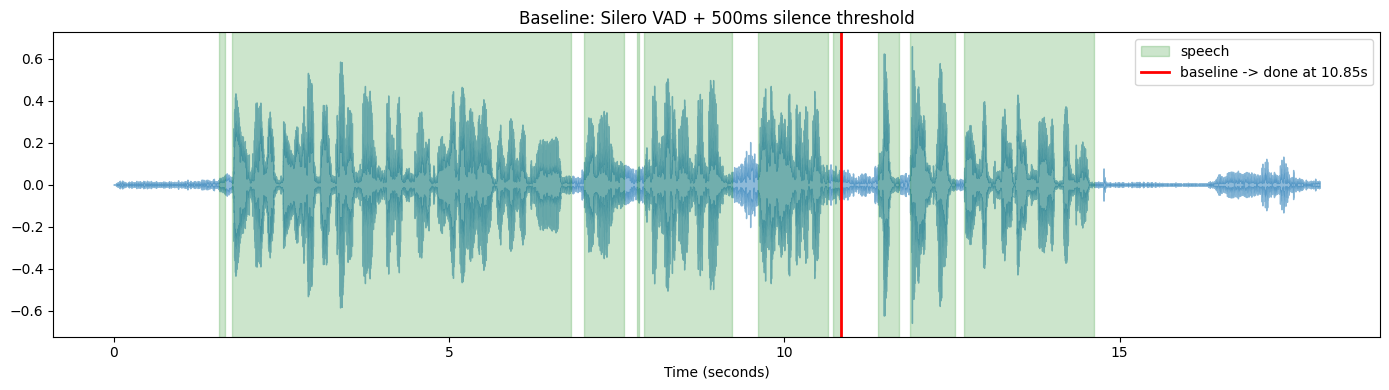

In [25]:
fig, ax = plt.subplots(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr, alpha=0.5, ax=ax)

for i, (s, e) in enumerate(speech_segments):
    ax.axvspan(s, e, color='green', alpha=0.2, label='speech' if i == 0 else None)

if predicted_done is not None:
    ax.axvline(predicted_done, color='red', linewidth=2,
               label=f'baseline -> done at {predicted_done:.2f}s')

ax.set_title('Baseline: Silero VAD + 500ms silence threshold')
ax.set_xlabel('Time (seconds)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Run on all clips

Let's run the smart pipeline on all the clips defined in `data/labels.json` and see how it performs against tricky pauses and 'wait' intents.

In [20]:
labels_path = os.path.join(DATA_DIR, 'labels.json')
BATCH_SIZE = 7
WAIT_SECONDS = 10

if not os.path.exists(labels_path):
    print('No labels.json yet.')
else:
    with open(labels_path) as f:
        labels = json.load(f)

    # prepare valid filenames
    valid_files = []
    for filename, clip in labels.items():
        if filename.startswith('_'):  # skip _meta
            continue
        clip_path = os.path.join(DATA_DIR, filename)
        if not os.path.exists(clip_path):
            print(f'  skip {filename} (file missing)')
            continue

        valid_files.append((filename, clip))

    rows = []

    total = len(valid_files)

    # batch loop
    for batch_start in range(0, total, BATCH_SIZE):
        batch_num = (batch_start // BATCH_SIZE) + 1
        batch = valid_files[batch_start: batch_start + BATCH_SIZE]
        print("\n")
        print("=" * 70)
        print(f"STARTING BATCH {batch_num}")
        print("=" * 70)
        for filename, clip in batch:
            clip_path = os.path.join(DATA_DIR, filename)
            y_clip, _ = librosa.load(clip_path, sr=SileroVAD.SAMPLE_RATE)
            cprobs = vad.get_speech_probabilities(y_clip)
            ctimes = np.array([t for t, _ in cprobs])
            cmask = np.array([p > VAD_THRESHOLD for _, p in cprobs])
            csegs = segments_from_mask(ctimes, cmask, chunk_dur)
            print("=========================================================")
            print(f"Processing : {filename}")
            pred, pred_class = predict_done_smart(y_clip,csegs, len(y_clip)/SileroVAD.SAMPLE_RATE, threshold_ms=500)
            gt = clip.get('user_finished_at_s')
            cls = clip.get('overall_class', '?')
            delta = (pred - gt) if (pred is not None and gt is not None) else None

            # Verdict logic (baseline can only judge timing, not class):
            # - cut    : predicted done before ground truth (cut user off mid-sentence)
            # - late   : predicted done significantly after ground truth (slow response)
            # - ok     : within 0.5s of ground truth
            # - none   : baseline never fired
            # - wait!  : flagged as wait-class (baseline cannot detect this)
            if pred_class == 'wait':
                verdict = 'wait!'
            elif pred is None:
                verdict = 'none'
            elif delta is None:
                verdict = '?'
            elif delta < -0.3:
                verdict = 'cut'
            elif delta > 0.5:
                verdict = 'late'
            else:
                verdict = 'ok'

            rows.append({
                'clip': filename,
                'gt_class': cls,
                'pred_class': pred_class,
                'gt': gt,
                'pred': pred,
                'delta': delta,
                'verdict': verdict,
                'text': clip.get('text', ''),
            })

        # batch summary
        print("\nBATCH COMPLETE")

        # wait before next batch
        if batch_start + BATCH_SIZE < total:
            print(f"\nWaiting {WAIT_SECONDS} seconds before next batch...\n")
            time.sleep(WAIT_SECONDS)

    # Final table
    print(f'{"clip":<14}{"gt_class":<11}{"pred_class":<11}{"gt":>6}{"pred":>7}{"delta":>7}  {"verdict":<24} text')
    print('-' * 110)
    for r in rows:
        gt = f'{r["gt"]:.2f}' if r['gt'] is not None else '--'
        pr = f'{r["pred"]:.2f}' if r['pred'] is not None else '--'
        dl = f'{r["delta"]:+.2f}' if r['delta'] is not None else '--'
        print(
            f'{r["clip"]:<14}'
            f'{r["gt_class"]:<11}'
            f'{r["pred_class"]:<11}'
            f'{gt:>6}'
            f'{pr:>7}'
            f'{dl:>7}  '
            f'{r["verdict"]:<24} '
            f'{r["text"][:55]}'
        )

    print()
    from collections import Counter
    counts = Counter(r['verdict'] for r in rows)
    print('Verdict counts:', dict(counts))



STARTING BATCH 1
Processing : clip-01.wav
Reviewed Text : I want to book a flight to Bangalore for next Tuesday morning.
LLM says: finished
Processing : clip-02.wav
Reviewed Text : I want to book a flight to Bangalore for next Tuesday.
LLM says: finished
Processing : clip-03.wav
Reviewed Text : I think I want a window seat please
LLM says: finished
Processing : clip-04.wav
Reviewed Text : Yes.
LLM says: finished
Processing : clip-05.wav
Reviewed Text : No, that's not right.
LLM says: finished
Processing : clip-06.wav
Reviewed Text : What was the price for the morning flight you mentioned earlier?
LLM says: finished
Processing : clip-07.wav
At Gap start : 1.888 Sending to LLM for Review
Reviewed Text : Please cancel my booking.
LLM says: finished

BATCH COMPLETE

Waiting 10 seconds before next batch...



STARTING BATCH 2
Processing : clip-08.wav
Reviewed Text : Okay.
LLM says: finished
Processing : clip-09.wav
Reviewed Text : I want to book a flight to Mumbai.
LLM says: finished
Proc